# 🤖 Klasifikasi Clickbait: IndoBERT
Notebook bersih fine-tuning IndoBERT untuk deteksi clickbait Bahasa Indonesia.

> **Urutan eksekusi:** Jalankan cell dari atas ke bawah secara berurutan.
> **Runtime:** Pastikan menggunakan GPU — `Runtime → Change runtime type → T4 GPU`

---
## ⚙️ TAHAP 0 — Setup: Install Library & Mount Drive

In [ ]:
!pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn tqdm -q
print('Library berhasil diinstall!')

Library berhasil diinstall!


In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device yang digunakan: {device}')

if device.type == 'cpu':
    print('⚠️  PERINGATAN: GPU tidak aktif! Training akan sangat lambat.')
    print('   Aktifkan GPU: Runtime → Change runtime type → T4 GPU')
else:
    print(f'✅ GPU siap: {torch.cuda.get_device_name(0)}')

Device yang digunakan: cuda
✅ GPU siap: Tesla T4


---
## 📥 TAHAP 1 — Muat & Periksa Dataset

Dataset dimuat: 15,000 baris, 3 kolom

Distribusi label (Jumlah):
label
non-clickbait    8710
clickbait        6290
Name: count, dtype: int64

Contoh data:
                                               title          label
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...  non-clickbait
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...  non-clickbait
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...      clickbait
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...  non-clickbait
4  Terkait Mayat Bayi Mengenaskan di Tangerang, S...  non-clickbait

Distribusi label (Persentase):
label
non-clickbait    58.066667
clickbait        41.933333
Name: proportion, dtype: float64


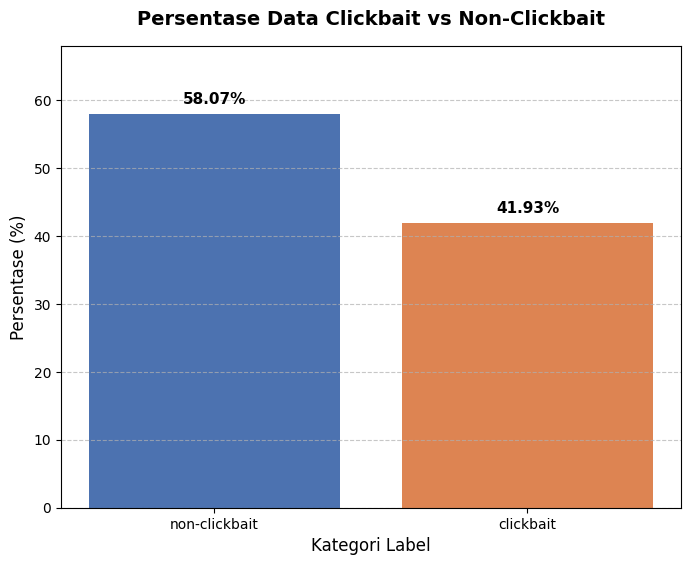

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

FILE_DATA = '/content/main.csv'

# Memuat data
df = pd.read_csv(FILE_DATA)
print(f'Dataset dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom')
print(f'\nDistribusi label (Jumlah):')
print(df['label'].value_counts())
print(f'\nContoh data:')
print(df[['title', 'label']].head())

# --- VISUALISASI PERSENTASE ---

# Menghitung persentase untuk masing-masing label
label_percentages = df['label'].value_counts(normalize=True) * 100

print(f'\nDistribusi label (Persentase):')
print(label_percentages)

# Mengatur ukuran figure (kanvas grafik)
plt.figure(figsize=(8, 6))

# Membuat grafik batang
# .astype(str) digunakan untuk memastikan label di sumbu X terbaca sebagai teks
bars = plt.bar(label_percentages.index.astype(str), label_percentages.values, color=['#4C72B0', '#DD8452'])

# Menambahkan angka persentase di atas masing-masing batang
for bar in bars:
    yval = bar.get_height()
    # Menambahkan teks di kordinat tengah batang (X) dan sedikit di atas tinggi batang (Y)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Menambahkan judul dan label sumbu
plt.title('Persentase Data Clickbait vs Non-Clickbait', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Label', fontsize=12)
plt.ylabel('Persentase (%)', fontsize=12)

# Mengatur batas maksimal sumbu Y sedikit lebih tinggi dari nilai tertinggi agar teks tidak terpotong
plt.ylim(0, max(label_percentages.values) + 10)

# Menampilkan grid pada sumbu Y untuk memudahkan pembacaan
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

---
## 🧹 TAHAP 2 — Preprocessing Teks

In [ ]:
import re

# Bersihkan URL dan spasi berlebih
# Sengaja TIDAK hapus ? dan ! karena itu sinyal kuat clickbait
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # hapus URL
    text = re.sub(r'\s+', ' ', text).strip()              # rapikan spasi
    return text

df['clean_text'] = df['title'].apply(clean_text)
df['label_id']   = (df['label'] == 'clickbait').astype(int)

print('Preprocessing selesai. Contoh hasil:')
df[['title', 'clean_text', 'label', 'label_id']].head()

Preprocessing selesai. Contoh hasil:


,title,clean_text,label,label_id
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...","Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,"Terkait Mayat Bayi Mengenaskan di Tangerang, S...","Terkait Mayat Bayi Mengenaskan di Tangerang, S...",non-clickbait,0


---
## ✂️ TAHAP 3 — Split Data (80% Train / 10% Val / 10% Test)

In [ ]:
from sklearn.model_selection import train_test_split

# Langkah 1: Pisah 90% train+val vs 10% test
train_val, df_test = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['label_id']
)
# Langkah 2: Pisah train+val menjadi 80% train vs 10% val
# (10% dari 90% = ~11.11%)
df_train, df_val = train_test_split(
    train_val, test_size=0.1111, random_state=42, stratify=train_val['label_id']
)

print(f'Train : {len(df_train):,} data (~80%)')
print(f'Val   : {len(df_val):,} data (~10%)')
print(f'Test  : {len(df_test):,} data (~10%)')
print(f'\nDistribusi label pada Test set:')
print(df_test['label'].value_counts())

Train : 12,000 data (~80%)
Val   : 1,500 data (~10%)
Test  : 1,500 data (~10%)

Distribusi label pada Test set:
label
non-clickbait    871
clickbait        629
Name: count, dtype: int64


---
## 🔤 TAHAP 4 — Tokenisasi IndoBERT
> IndoBERT punya tokenizer sendiri (WordPiece) yang sudah dilatih untuk Bahasa Indonesia.

In [ ]:
from transformers import BertTokenizer

MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN    = 64  # Judul berita jarang > 64 token, hemat memori GPU

print(f'Mengunduh tokenizer dari: {MODEL_NAME}')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer berhasil dimuat!')

# Contoh tokenisasi
contoh = df['clean_text'].iloc[0]
tokens = tokenizer.tokenize(contoh)
print(f'\nContoh kalimat : {contoh}')
print(f'Hasil token    : {tokens}')
print(f'Jumlah token   : {len(tokens)}')

Mengunduh tokenizer dari: indobenchmark/indobert-base-p1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer berhasil dimuat!

Contoh kalimat : Masuk Radar Pilwalkot Medan, Menantu Jokowi Bertemu DPW NasDem Sumut
Hasil token    : ['masuk', 'radar', 'pil', '##walk', '##ot', 'medan', ',', 'menantu', 'jokowi', 'bertemu', 'dpw', 'nasdem', 'sumut']
Jumlah token   : 13


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

def tokenize_batch(texts):
    """Tokenisasi sekelompok teks sekaligus."""
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )

print('Tokenisasi data Train...')
train_enc = tokenize_batch(df_train['clean_text'])
print('Tokenisasi data Val...')
val_enc   = tokenize_batch(df_val['clean_text'])
print('Tokenisasi data Test...')
test_enc  = tokenize_batch(df_test['clean_text'])

print(f'\nShape input_ids train: {train_enc["input_ids"].shape}')
print('Tokenisasi selesai!')

Tokenisasi data Train...
Tokenisasi data Val...
Tokenisasi data Test...

Shape input_ids train: torch.Size([12000, 64])
Tokenisasi selesai!


---
## 📦 TAHAP 5 — Dataset & DataLoader

In [ ]:
class ClickbaitDataset(Dataset):
    """Custom Dataset untuk IndoBERT."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

BATCH_SIZE = 16  # Kurangi ke 8 jika GPU OOM (out of memory)

train_loader = DataLoader(ClickbaitDataset(train_enc, df_train['label_id']),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ClickbaitDataset(val_enc, df_val['label_id']),
                          batch_size=BATCH_SIZE)
test_loader  = DataLoader(ClickbaitDataset(test_enc, df_test['label_id']),
                          batch_size=BATCH_SIZE)

print(f'Jumlah batch Train : {len(train_loader)}')
print(f'Jumlah batch Val   : {len(val_loader)}')
print(f'Jumlah batch Test  : {len(test_loader)}')

Jumlah batch Train : 750
Jumlah batch Val   : 94
Jumlah batch Test  : 94


---
## 🏗️ TAHAP 6 — Setup Model IndoBERT

In [ ]:
from transformers import BertConfig, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import numpy as np

print(f'Mengunduh model IndoBERT dari: {MODEL_NAME}')

# --- INI BAHAGIAN YANG DITAMBAHKAN (POIN 1) ---
# Modifikasi konfigurasi bawaan untuk memperbesar dropout
custom_config = BertConfig.from_pretrained(
    MODEL_NAME,
    hidden_dropout_prob=0.3,          # Dropout dinaikkan menjadi 30%
    attention_probs_dropout_prob=0.3, # Dropout attention dinaikkan menjadi 30%
    num_labels=2
)

# Terapkan konfigurasi tersebut ke dalam model
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=custom_config
)

model.to(device)
print('Model berhasil dimuat ke', device)

# Hitung jumlah parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameter    : {total_params:,}')
print(f'Parameter trainable: {trainable_params:,}')

Mengunduh model IndoBERT dari: indobenchmark/indobert-base-p1


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model berhasil dimuat ke cuda
Total parameter    : 124,442,882
Parameter trainable: 124,442,882


In [ ]:
EPOCHS = 5
LR     = 5e-6

optimizer   = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,  # 10% langkah pertama untuk warmup
    num_training_steps=total_steps
)

# Class weight untuk handle imbalanced dataset
bobot_kelas   = compute_class_weight('balanced',
                    classes=np.unique(df_train['label_id']),
                    y=df_train['label_id'])
tensor_bobot  = torch.tensor(bobot_kelas, dtype=torch.float).to(device)
loss_fn       = nn.CrossEntropyLoss(weight=tensor_bobot)

print(f'Total steps training : {total_steps:,}')
print(f'Warmup steps         : {total_steps // 10:,}')
print(f'Class weights        : {bobot_kelas}')
print('Optimizer & scheduler siap!')

Total steps training : 3,750
Warmup steps         : 375
Class weights        : [0.86107922 1.19236884]
Optimizer & scheduler siap!


---
## 🔁 TAHAP 7 — Fungsi Training & Evaluasi Per Epoch

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_epoch(model, loader):
    """Satu epoch training."""
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch in tqdm(loader, desc='  Training', leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        out  = model(**batch)
        loss = loss_fn(out.logits, batch['labels'])
        loss.backward()

        # Gradient clipping — mencegah exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds  += torch.argmax(out.logits, dim=1).cpu().tolist()
        all_labels += batch['labels'].cpu().tolist()

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc

def eval_epoch(model, loader, desc='Evaluasi'):
    """Evaluasi model pada satu loader (val atau test)."""
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  {desc}', leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            out   = model(**batch)

            # --- BAGIAN INI DITAMBAHKAN UNTUK MENGHITUNG VAL LOSS ---
            loss  = loss_fn(out.logits, batch['labels'])
            total_loss += loss.item()
            # ---------------------------------------------------------

            all_preds  += torch.argmax(out.logits, dim=1).cpu().tolist()
            all_labels += batch['labels'].cpu().tolist()

    avg_loss = total_loss / len(loader)
    acc    = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds,
                target_names=['Faktual', 'Clickbait'], digits=4)
    cm     = confusion_matrix(all_labels, all_preds)

    # avg_loss ditambahkan ke output return
    return avg_loss, acc, report, cm, all_preds, all_labels

print('Fungsi train_epoch dan eval_epoch siap!')

Fungsi train_epoch dan eval_epoch siap!


---
## 🚀 TAHAP 8 — Fine-Tuning IndoBERT
> Epoch terbaik otomatis disimpan ke Google Drive berdasarkan Val Accuracy tertinggi.

In [ ]:
import os
import matplotlib.pyplot as plt

SAVE_PATH    = '/content/drive/MyDrive/Proyek_NLP_Clickbait/best-indobert-clickbait'
os.makedirs(SAVE_PATH, exist_ok=True)

best_val_acc     = 0
# val_loss ditambahkan ke dalam dictionary history
history          = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Memulai Fine-Tuning IndoBERT...')
print('=' * 60)

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 40)

    train_loss, train_acc = train_epoch(model, train_loader)

    # val_loss ditangkap dari hasil return eval_epoch
    val_loss, val_acc, val_report, val_cm, _, _ = eval_epoch(model, val_loader, desc='Validasi')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss) # Simpan val loss
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'  Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}')
    print(f'  Train Acc  : {train_acc*100:.2f}% | Val Acc  : {val_acc*100:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f'  ✅ Model terbaik disimpan! (Val Acc: {val_acc*100:.2f}%)')

print('\n' + '=' * 60)
print(f'Training selesai. Best Val Accuracy: {best_val_acc*100:.2f}%')

Memulai Fine-Tuning IndoBERT...

Epoch 1/5
----------------------------------------



  Training:  25%|██▍       | 184/750 [39:28<1:55:29, 12.24s/it]

---
## 📈 TAHAP 9 — Grafik Training

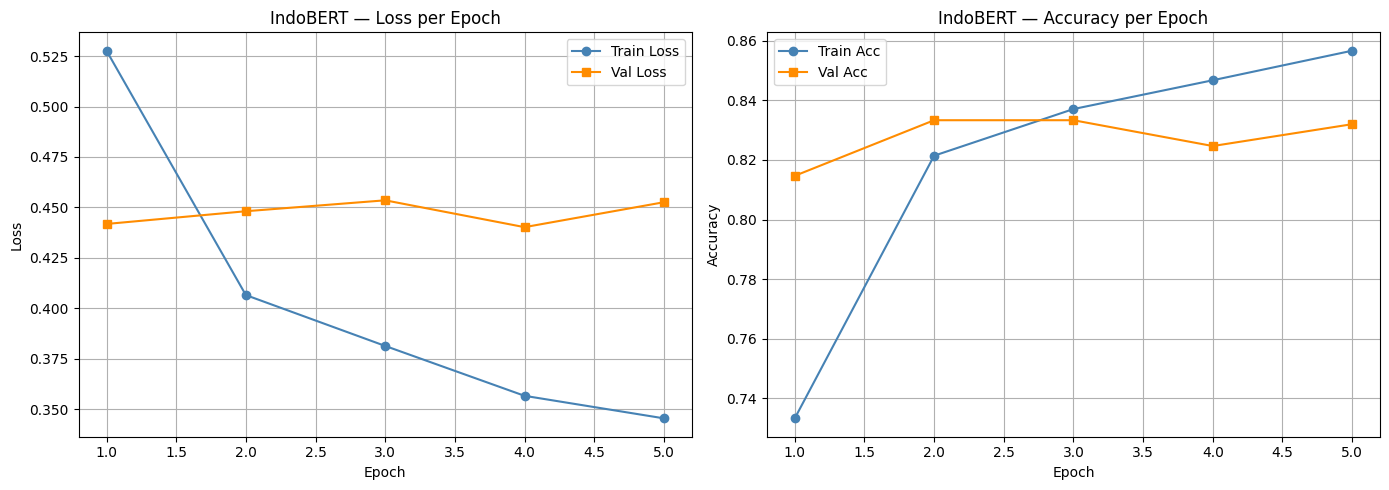

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Grafik 1: Loss (Train & Validation) -> INI YANG DIUBAH
# ---------------------------------------------------------
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
# Tambahkan baris di bawah ini untuk menampilkan Validation Loss:
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val Loss', color='darkorange')

axes[0].set_title('IndoBERT — Loss per Epoch') # Judul diubah agar mencakup keduanya
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# ---------------------------------------------------------
# Grafik 2: Accuracy (Train & Validation) -> TETAP
# ---------------------------------------------------------
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Acc', color='steelblue')
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val Acc', color='darkorange')
axes[1].set_title('IndoBERT — Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 🧪 TAHAP 10 — Evaluasi Final pada Data Test
> Model yang dimuat adalah versi terbaik yang disimpan saat training.

In [ ]:
from transformers import BertForSequenceClassification
import torch.nn.functional as F
import numpy as np
import seaborn as sns

# Muat ulang model terbaik
print(f'Memuat model terbaik dari: {SAVE_PATH}')
model_best = BertForSequenceClassification.from_pretrained(SAVE_PATH)
model_best.to(device)
model_best.eval()
print('Model terbaik siap!')

Memuat model terbaik dari: /content/drive/MyDrive/Proyek_NLP_Clickbait/best-indobert-clickbait


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model terbaik siap!


In [ ]:
# Kumpulkan probabilitas prediksi
semua_prob       = []
semua_label_asli = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluasi Test'):
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model_best(**batch)
        prob  = F.softmax(out.logits, dim=1)[:, 1]  # probabilitas kelas Clickbait
        semua_prob.extend(prob.cpu().tolist())
        semua_label_asli.extend(batch['labels'].cpu().tolist())

print(f'Evaluasi selesai! Total sampel test: {len(semua_label_asli)}')

Evaluasi Test: 100%|██████████| 94/94 [00:05<00:00, 16.45it/s]

Evaluasi selesai! Total sampel test: 1500


    EVALUATION METRICS — IndoBERT (Threshold 0.50)
  Accuracy : 81.93%
-------------------------------------------------------
              precision    recall  f1-score   support

     Faktual     0.8205    0.8817    0.8500       871
   Clickbait     0.8174    0.7329    0.7728       629

    accuracy                         0.8193      1500
   macro avg     0.8189    0.8073    0.8114      1500
weighted avg     0.8192    0.8193    0.8177      1500



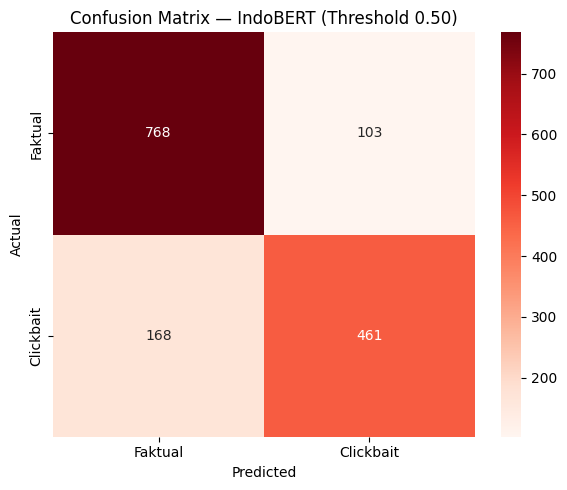

In [ ]:
# Tampilkan hasil pada threshold 0.50 (standar)
pred_050 = (np.array(semua_prob) >= 0.50).astype(int)

print('=' * 55)
print('    EVALUATION METRICS — IndoBERT (Threshold 0.50)')
print('=' * 55)
print(f'  Accuracy : {accuracy_score(semua_label_asli, pred_050)*100:.2f}%')
print('-' * 55)
print(classification_report(semua_label_asli, pred_050,
      target_names=['Faktual', 'Clickbait'], digits=4))

cm_050 = confusion_matrix(semua_label_asli, pred_050)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_050, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Faktual', 'Clickbait'],
            yticklabels=['Faktual', 'Clickbait'])
plt.title('Confusion Matrix — IndoBERT (Threshold 0.50)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

    EVALUATION METRICS — IndoBERT (Threshold 0.40)
  Accuracy : 81.47%
-------------------------------------------------------
              precision    recall  f1-score   support

     Faktual     0.8343    0.8496    0.8419       871
   Clickbait     0.7863    0.7663    0.7762       629

    accuracy                         0.8147      1500
   macro avg     0.8103    0.8079    0.8090      1500
weighted avg     0.8142    0.8147    0.8143      1500



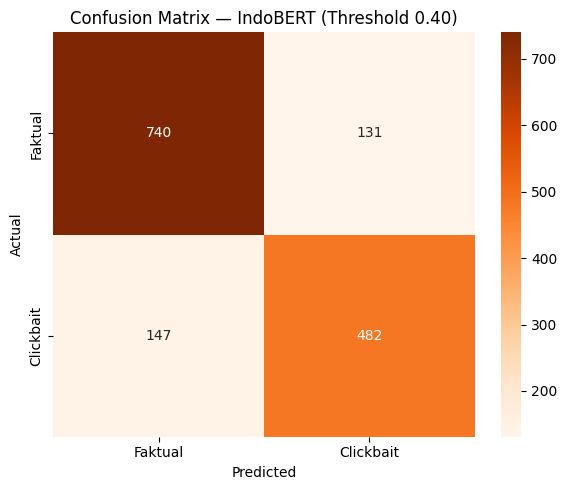

In [ ]:
# Perbandingan threshold 0.50 vs 0.40
# Threshold 0.40 meningkatkan Recall Clickbait tapi menurunkan Precision
pred_040 = (np.array(semua_prob) >= 0.40).astype(int)

print('=' * 55)
print('    EVALUATION METRICS — IndoBERT (Threshold 0.40)')
print('=' * 55)
print(f'  Accuracy : {accuracy_score(semua_label_asli, pred_040)*100:.2f}%')
print('-' * 55)
print(classification_report(semua_label_asli, pred_040,
      target_names=['Faktual', 'Clickbait'], digits=4))

cm_040 = confusion_matrix(semua_label_asli, pred_040)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_040, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Faktual', 'Clickbait'],
            yticklabels=['Faktual', 'Clickbait'])
plt.title('Confusion Matrix — IndoBERT (Threshold 0.40)')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

---
## 🔍 TAHAP 11 — Uji Prediksi Manual

In [ ]:
def prediksi_judul(judul, threshold=0.50):
    """Prediksi satu judul berita menggunakan IndoBERT."""
    bersih = re.sub(r'http\S+|www\S+|https\S+', '', str(judul))
    bersih = re.sub(r'\s+', ' ', bersih).strip()

    enc = tokenizer(bersih, truncation=True, padding='max_length',
                    max_length=MAX_LEN, return_tensors='pt')
    enc = {k: v.to(device) for k, v in enc.items()}

    model_best.eval()
    with torch.no_grad():
        out  = model_best(**enc)
        prob = F.softmax(out.logits, dim=1)[0]

    prob_clickbait = prob[1].item()
    label = 'CLICKBAIT 🔴' if prob_clickbait >= threshold else 'FAKTUAL 🟢'

    print(f'Judul  : {judul}')
    print(f'Hasil  : {label}')
    print(f'Prob. Clickbait : {prob_clickbait*100:.2f}%')
    print(f'Prob. Faktual   : {prob[0].item()*100:.2f}%')
    print('-' * 60)


# Contoh prediksi
judul_tes = [
    'Astaga! Artis Ini Ketahuan Makan Nasi Padang Pakai Tangan Kiri, Bikin Netizen Melongo!',
    'Pemerintah Provinsi Riau Menetapkan UMP Tahun 2026 Sebesar 3.5 Juta Rupiah',
    '5 Rahasia Cepat Kaya Tanpa Kerja yang Disembunyikan Para Miliarder',
    'Bank Indonesia Mempertahankan Suku Bunga Acuan di Level 6 Persen'
]

print('--- UJI PREDIKSI MANUAL ---\n')
for j in judul_tes:
    prediksi_judul(j)

--- UJI PREDIKSI MANUAL ---

Judul  : Astaga! Artis Ini Ketahuan Makan Nasi Padang Pakai Tangan Kiri, Bikin Netizen Melongo!
Hasil  : CLICKBAIT 🔴
Prob. Clickbait : 99.51%
Prob. Faktual   : 0.49%
------------------------------------------------------------
Judul  : Pemerintah Provinsi Riau Menetapkan UMP Tahun 2026 Sebesar 3.5 Juta Rupiah
Hasil  : FAKTUAL 🟢
Prob. Clickbait : 2.60%
Prob. Faktual   : 97.40%
------------------------------------------------------------
Judul  : 5 Rahasia Cepat Kaya Tanpa Kerja yang Disembunyikan Para Miliarder
Hasil  : CLICKBAIT 🔴
Prob. Clickbait : 99.57%
Prob. Faktual   : 0.43%
------------------------------------------------------------
Judul  : Bank Indonesia Mempertahankan Suku Bunga Acuan di Level 6 Persen
Hasil  : FAKTUAL 🟢
Prob. Clickbait : 2.16%
Prob. Faktual   : 97.84%
------------------------------------------------------------


---
## 💾 TAHAP 12 — Model Sudah Tersimpan
> Model terbaik otomatis tersimpan saat training (Tahap 8). Cell ini hanya konfirmasi.

In [ ]:
import os

print('Isi folder model yang disimpan:')
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, f))
    print(f'  {f:<35} {size/1024/1024:.1f} MB')

print(f'\n✅ Model IndoBERT tersimpan di:')
print(f'   {SAVE_PATH}')
print(f'\nUntuk load ulang di notebook lain:')
print(f"   model = BertForSequenceClassification.from_pretrained('{SAVE_PATH}')")
print(f"   tokenizer = BertTokenizer.from_pretrained('{SAVE_PATH}')")

Isi folder model yang disimpan:
  config.json                         0.0 MB
  model.safetensors                   474.7 MB
  tokenizer.json                      0.7 MB
  tokenizer_config.json               0.0 MB

✅ Model IndoBERT tersimpan di:
   /content/drive/MyDrive/Proyek_NLP_Clickbait/best-indobert-clickbait

Untuk load ulang di notebook lain:
   model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/Proyek_NLP_Clickbait/best-indobert-clickbait')
   tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/Proyek_NLP_Clickbait/best-indobert-clickbait')
